## Import Libraries

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Define Image Processing Function

In [16]:
"""Circle detection and pre-log FFC differential analysis utilities for PyScript."""

import base64
import io

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

DEBUG = True
# Coefficient of Variation (CV = std/mean) threshold for anti-diagonal air circles.
# AIR_CV_THRESHOLD=0.05 means CV > 5% indicates likely ROI contamination by acrylic wall/noise.
AIR_CV_THRESHOLD = 0.05
AIR_DIAGONAL_VALIDATION_CODE = "E_CIRCLE_AIR_ROI"
AIR_DIAGONAL_VALIDATION_ERROR = (
    f"{AIR_DIAGONAL_VALIDATION_CODE}: Validation Failed: The 4 Air reference circles on the anti-diagonal show inconsistent intensities. "
    "Please adjust the Minimum/Maximum Diameter or Threshold parameters to ensure the circles fit strictly "
    "inside the empty physical holes."
)


def _load_image(file_bytes):
    """Load TIFF bytes into a NumPy array, compatible with PyScript runtime."""
    nparr = np.frombuffer(file_bytes, np.uint8)
    img_16bit = cv2.imdecode(nparr, cv2.IMREAD_UNCHANGED)
    if img_16bit is None:
        pil_img = Image.open(io.BytesIO(file_bytes))
        img_16bit = np.array(pil_img)
    return img_16bit


def _load_and_validate_image(file_bytes):
    """Validate TIFF grayscale input and normalize any 16-bit NumPy dtype to uint16."""
    try:
        pil_img = Image.open(io.BytesIO(file_bytes))
    except Exception as exc:
        raise ValueError(f"Image format validation failed: unable to read image bytes ({exc}).") from exc

    img_format = (pil_img.format or "unknown").upper()
    if img_format != "TIFF":
        raise ValueError(
            f"Image format validation failed: expected 16-bit grayscale TIFF, got format '{img_format}'."
        )

    img = np.array(pil_img)
    if img.ndim != 2:
        raise ValueError(
            f"Image format validation failed: expected grayscale TIFF (single channel), got shape {img.shape}."
        )
    if img.dtype.kind != "u" or img.dtype.itemsize != 2:
        raise ValueError(
            f"Image format validation failed: expected 16-bit grayscale TIFF, got dtype '{img.dtype}'."
        )
    return img.astype(np.uint16, copy=False)


def _numpy_to_base64(img_array):
    """Convert a NumPy image array into base64 PNG for browser display."""
    if len(img_array.shape) == 2:
        pil_img = Image.fromarray(img_array, mode="L")
    else:
        pil_img = Image.fromarray(img_array, mode="RGB")

    buffer = io.BytesIO()
    pil_img.save(buffer, format="PNG")
    buffer.seek(0)
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


def process_tiff_image(file_bytes, params):
    """Detect candidate circles from TIFF image bytes."""
    try:
        img_16bit = _load_and_validate_image(file_bytes)

        threshold_value = params.get("threshold_value", 24000)
        min_diameter = params.get("min_diameter", 50)
        max_diameter = params.get("max_diameter", 357)
        min_area = np.pi * (min_diameter / 2) ** 2
        max_area = np.pi * (max_diameter / 2) ** 2
        min_circularity = params.get("min_circularity", 0.6)
        min_solidity = params.get("min_solidity", 0.7)
        min_aspect_ratio = params.get("min_aspect_ratio", 0.7)
        max_aspect_ratio = params.get("max_aspect_ratio", 1.3)
        expected_count = params.get("expected_count", 4)
        grid_cols = params.get("grid_cols", 4)

        binary_mask = np.zeros_like(img_16bit, dtype=np.uint8)
        binary_mask[img_16bit < threshold_value] = 255
        kernel = np.ones((5, 5), np.uint8)
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)

        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        valid_circles = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < min_area or area > max_area:
                continue

            (x, y), radius = cv2.minEnclosingCircle(cnt)
            center = (int(x), int(y))
            radius = int(radius)

            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0:
                continue

            circularity = 4 * np.pi * (area / (perimeter * perimeter))
            if circularity < min_circularity:
                continue

            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            if hull_area == 0:
                continue
            solidity = area / hull_area
            if solidity < min_solidity:
                continue

            rect = cv2.minAreaRect(cnt)
            width, height = rect[1]
            if width == 0 or height == 0:
                continue
            aspect_ratio = max(width, height) / min(width, height)
            if aspect_ratio < min_aspect_ratio or aspect_ratio > max_aspect_ratio:
                continue

            valid_circles.append(
                {
                    "center": center,
                    "radius": radius,
                    "contour": cnt,
                    "area": area,
                    "circularity": circularity,
                    "solidity": solidity,
                    "aspect_ratio": aspect_ratio,
                }
            )

        if len(valid_circles) > expected_count:
            filtered = []
            for circle in valid_circles:
                is_duplicate = False
                for j, other in enumerate(filtered):
                    dist = np.sqrt(
                        (circle["center"][0] - other["center"][0]) ** 2
                        + (circle["center"][1] - other["center"][1]) ** 2
                    )
                    avg_radius = (circle["radius"] + other["radius"]) / 2
                    if dist < avg_radius * 0.8:
                        is_duplicate = True
                        if circle["circularity"] > other["circularity"]:
                            filtered[j] = circle
                        break
                if not is_duplicate:
                    filtered.append(circle)
            valid_circles = filtered

        if len(valid_circles) >= expected_count:
            valid_circles.sort(key=lambda c: c["center"][1])
            num_rows = expected_count // grid_cols
            sorted_final = []
            for row_idx in range(num_rows):
                start_idx = row_idx * grid_cols
                end_idx = start_idx + grid_cols
                if end_idx <= len(valid_circles):
                    row = valid_circles[start_idx:end_idx]
                    row.sort(key=lambda c: c["center"][0])
                    sorted_final.extend(row)
            if len(sorted_final) == expected_count:
                valid_circles = sorted_final
            else:
                valid_circles.sort(key=lambda c: (c["center"][1] // 200, c["center"][0]))
        else:
            valid_circles.sort(key=lambda c: (c["center"][1] // 200, c["center"][0]))

        img_display = cv2.normalize(img_16bit, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
        img_rgb = cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB)
        debug_mask_rgb = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)

        results = []
        for i, item in enumerate(valid_circles):
            center = item["center"]
            radius = item["radius"]

            mask_sampling = np.zeros_like(img_16bit, dtype=np.uint8)
            cv2.circle(mask_sampling, center, int(radius * 0.7), 255, -1)
            mean_val = cv2.mean(img_16bit, mask=mask_sampling)[0]

            cv2.circle(img_rgb, center, radius, (0, 255, 0), 4)
            cv2.putText(
                img_rgb,
                str(i + 1),
                (center[0] - 20, center[1] + 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.5,
                (0, 100, 255),
                4,
            )

            cv2.circle(debug_mask_rgb, center, radius, (0, 0, 255), 4)
            cv2.putText(
                debug_mask_rgb,
                str(i + 1),
                (center[0] - 20, center[1] + 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.5,
                (0, 100, 255),
                4,
            )

            results.append(
                {
                    "id": i + 1,
                    "center": center,
                    "radius": radius,
                    "mean_value": mean_val,
                    "circularity": item["circularity"],
                    "solidity": item["solidity"],
                    "aspect_ratio": item["aspect_ratio"],
                }
            )

        return {
            "circles": results,
            "detection_image": _numpy_to_base64(img_rgb),
            "mask_image": _numpy_to_base64(debug_mask_rgb),
            "count": len(results),
        }

    except Exception as e:
        raise ValueError(f"Circle detection failed: {str(e)}") from e


def detect_grid_from_diagonal(file_bytes, initial_results, grid_size=None):
    """Extrapolate full grid positions from detected diagonal circles."""
    try:
        img_16bit = _load_and_validate_image(file_bytes)

        circles = initial_results["circles"]
        detected_count = len(circles)
        if detected_count != 4:
            raise ValueError(
                "Circle anchor validation failed: expected exactly 4 detected anchor circles "
                f"for diagonal extrapolation, found {detected_count}. "
                "Adjust circle detection parameters in the UI and retry."
            )
        if grid_size is None:
            grid_size = 4
        if int(grid_size) != 4:
            raise ValueError(f"Grid validation failed: expected 4x4 grid, received grid_size={grid_size}.")

        positions = [(c["center"][0], c["center"][1]) for c in circles]
        x_coords = [pos[0] for pos in positions]
        y_coords = [pos[1] for pos in positions]

        x_spacings = [x_coords[i + 1] - x_coords[i] for i in range(len(x_coords) - 1)]
        y_spacings = [y_coords[i + 1] - y_coords[i] for i in range(len(y_coords) - 1)]
        mean_x_spacing = np.mean(x_spacings)
        mean_y_spacing = np.mean(y_spacings)

        ref_x, ref_y = positions[0]
        x_positions = [int(ref_x + col * mean_x_spacing) for col in range(grid_size)]
        y_positions = [int(ref_y + row * mean_y_spacing) for row in range(grid_size)]

        grid_results = []
        for row in range(grid_size):
            for col in range(grid_size):
                grid_results.append(
                    {
                        "id": row * grid_size + col + 1,
                        "grid_pos": (row, col),
                        "center": (x_positions[col], y_positions[row]),
                        "radius": 103,
                    }
                )

        img_display = cv2.normalize(img_16bit, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
        img_rgb = cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB)

        for item in grid_results:
            center = item["center"]
            cv2.circle(img_rgb, center, item["radius"], (0, 255, 255), 3)
            cv2.circle(img_rgb, center, 5, (255, 0, 0), -1)
            cv2.putText(
                img_rgb,
                str(item["id"]),
                (center[0] - 20, center[1] + 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.2,
                (0, 255, 0),
                3,
            )

        if len(grid_results) != 16:
            raise ValueError(
                f"Circle grid validation failed: expected exactly 16 circles in 4x4 grid, found {len(grid_results)}."
            )

        for item in grid_results:
            cx, cy = item["center"]
            if cx < 0 or cy < 0 or cx >= img_16bit.shape[1] or cy >= img_16bit.shape[0]:
                raise ValueError(
                    f"Circle grid validation failed: extrapolated center {item['center']} is out of image bounds."
                )

        return {
            "grid": grid_results,
            "grid_image": _numpy_to_base64(img_rgb),
            "x_spacing": mean_x_spacing,
            "y_spacing": mean_y_spacing,
        }

    except Exception as e:
        raise ValueError(f"Grid extrapolation failed: {str(e)}") from e


def analyze_grid_histograms(file_bytes, grid_results):
    """Keep existing histogram output for UI compatibility."""
    try:
        img_16bit = _load_image(file_bytes)
        if img_16bit is None:
            return None

        grid_data = grid_results["grid"]
        histogram_stats = []
        max_row = max(item["grid_pos"][0] for item in grid_data)
        max_col = max(item["grid_pos"][1] for item in grid_data)
        grid_size = max(max_row, max_col) + 1

        grid_lookup = {(item["grid_pos"][0], item["grid_pos"][1]): item for item in grid_data}
        measured_pixels = {}
        global_min = None
        global_max = None

        # Collect all pixel distributions first so every subplot can use the same
        # x-axis range for fair visual comparison across positions.
        for pos, item in grid_lookup.items():
            mask = np.zeros_like(img_16bit, dtype=np.uint8)
            cv2.circle(mask, item["center"], int(item["radius"] * 0.7), 255, -1)
            pixel_values = img_16bit[mask == 255]
            if len(pixel_values) == 0:
                continue
            measured_pixels[pos] = pixel_values
            local_min = float(np.min(pixel_values))
            local_max = float(np.max(pixel_values))
            global_min = local_min if global_min is None else min(global_min, local_min)
            global_max = local_max if global_max is None else max(global_max, local_max)

        fig_size = max(12, grid_size * 4)
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(fig_size, fig_size))
        fig.suptitle(
            f"Histogram Distribution - {grid_size}x{grid_size} Grid (Anti-Diagonal Layout)",
            fontsize=16,
            fontweight="bold",
        )

        if grid_size == 1:
            axes = np.array([[axes]])
        elif grid_size > 1 and len(axes.shape) == 1:
            axes = axes.reshape(grid_size, 1)

        for row in range(grid_size):
            for col in range(grid_size):
                display_col = (grid_size - 1) - col
                ax = axes[row, display_col]
                grid_pos_id = row * grid_size + col + 1
                if (row, col) not in measured_pixels:
                    ax.text(
                        0.5,
                        0.5,
                        f"Position [{row},{col}]\nNo Data",
                        transform=ax.transAxes,
                        ha="center",
                        va="center",
                        fontsize=12,
                        color="gray",
                    )
                    ax.set_title(f"Pos {grid_pos_id} [{row},{col}]", fontsize=10, fontweight="bold", color="gray")
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue

                item = grid_lookup[(row, col)]
                pixel_values = measured_pixels[(row, col)]

                mean_val = float(np.mean(pixel_values))
                median_val = float(np.median(pixel_values))
                std_val = float(np.std(pixel_values))
                min_val = float(np.min(pixel_values))
                max_val = float(np.max(pixel_values))

                histogram_stats.append(
                    {
                        "grid_pos": (row, col),
                        "position_id": grid_pos_id,
                        "center": item["center"],
                        "radius": float(item["radius"]),
                        "roi_area": float(np.pi * (float(item["radius"]) ** 2)),
                        "mean": mean_val,
                        "median": median_val,
                        "std": std_val,
                        "min": min_val,
                        "max": max_val,
                        "pixel_count": len(pixel_values),
                    }
                )

                ax.hist(pixel_values, bins=50, color="steelblue", alpha=0.7, edgecolor="black")
                ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.1f}")
                ax.axvline(
                    median_val,
                    color="green",
                    linestyle="--",
                    linewidth=2,
                    label=f"Median: {median_val:.1f}",
                )
                ax.set_title(f"Pos {grid_pos_id} [{row},{col}]", fontsize=10, fontweight="bold")
                ax.set_xlabel("Pixel Value (16-bit)", fontsize=8)
                ax.set_ylabel("Frequency", fontsize=8)
                if global_min is not None and global_max is not None:
                    if global_max == global_min:
                        ax.set_xlim([global_min - 0.5, global_max + 0.5])
                    else:
                        pad = (global_max - global_min) * 0.02
                        ax.set_xlim([global_min - pad, global_max + pad])
                ax.legend(fontsize=7, loc="upper right")
                ax.grid(True, alpha=0.3)

                stats_text = f"Min: {min_val:.0f}\nMax: {max_val:.0f}\nStd: {std_val:.1f}"
                ax.text(
                    0.02,
                    0.98,
                    stats_text,
                    transform=ax.transAxes,
                    fontsize=7,
                    verticalalignment="top",
                    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
                )

        plt.tight_layout()
        buffer = io.BytesIO()
        plt.savefig(buffer, format="png", dpi=100, bbox_inches="tight")
        buffer.seek(0)
        histogram_image = base64.b64encode(buffer.getvalue()).decode("utf-8")
        plt.close()

        roi_areas = np.array([float(item["roi_area"]) for item in histogram_stats], dtype=float)
        roi_area_mean = float(np.mean(roi_areas)) if len(roi_areas) else 0.0
        roi_area_std = float(np.std(roi_areas)) if len(roi_areas) else 0.0
        roi_area_min = float(np.min(roi_areas)) if len(roi_areas) else 0.0
        roi_area_max = float(np.max(roi_areas)) if len(roi_areas) else 0.0

        return {
            "histogram_stats": histogram_stats,
            "histogram_image": histogram_image,
            "roi_area_mean": roi_area_mean,
            "roi_area_std": roi_area_std,
            "roi_area_min": roi_area_min,
            "roi_area_max": roi_area_max,
            "roi_area_equal": bool(np.allclose(roi_areas, roi_areas[0], rtol=0.0, atol=1e-6)) if len(roi_areas) else False,
        }

    except Exception as e:
        if DEBUG:
            print(f"Error in analyze_grid_histograms: {str(e)}")
        return None


def visualize_circle_invalid_roi(file_bytes, grid_results):
    """Build guidance overlay highlighting anti-diagonal air reference ROIs."""
    try:
        img_16bit = _load_and_validate_image(file_bytes)
        grid_data = grid_results["grid"]
        img_display = cv2.normalize(img_16bit, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
        img_rgb = cv2.cvtColor(img_display, cv2.COLOR_GRAY2RGB)

        for item in grid_data:
            row, col = item["grid_pos"]
            center = tuple(item["center"])
            radius = int(item["radius"])
            is_anti_air = (row + col) == 3
            color = (255, 0, 0) if is_anti_air else (0, 255, 0)
            label_prefix = "AIR" if is_anti_air else "ROI"
            cv2.circle(img_rgb, center, radius, color, 3)
            cv2.circle(img_rgb, center, int(radius * 0.7), color, 2)
            cv2.putText(
                img_rgb,
                f"{label_prefix}[{row},{col}]",
                (center[0] - 85, center[1] - radius - 12),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                color,
                2,
            )

        return {
            "invalid_roi_image": _numpy_to_base64(img_rgb),
            "hint": "Anti-diagonal AIR ROIs are highlighted in red. Tune threshold and diameter so each ROI stays inside hole area.",
        }
    except Exception as e:
        raise ValueError(f"Circle invalid ROI visualization failed: {str(e)}") from e


def compare_diagonals(file_bytes, grid_results, params=None):
    """
    Pre-log FFC analysis for 4x4 circle grid.

    Physics model used (differential method):
            μ_coal = (P_coal - P_air) / x_coal

    Where:
    - P_air is taken from anti_air_mean (mean pixel value of the anti-diagonal air circles)
    - x_coal = 6 mm (coal thickness only)
    - Acrylic attenuation cancels out because both paths include identical acrylic layers.
    """
    try:
        img_16bit = _load_and_validate_image(file_bytes)
        params = params or {}
        air_cv_threshold = float(params.get("air_cv_threshold", AIR_CV_THRESHOLD))

        grid_data = grid_results["grid"]
        circle_count = len(grid_data)
        if circle_count != 16:
            raise ValueError(
                "Circle count validation failed: expected exactly 16 circles before differential physics "
                f"calculation, found {circle_count}. "
                "Adjust circle detection parameters in the UI and retry."
            )

        diagonal_items = []
        anti_diagonal_items = []
        upper_anti_diagonal_items = []
        lower_anti_diagonal_items = []
        max_row = max(item["grid_pos"][0] for item in grid_data)
        max_col = max(item["grid_pos"][1] for item in grid_data)
        grid_size = max(max_row, max_col) + 1
        anti_diagonal_sum = grid_size - 1

        for item in grid_data:
            row, col = item["grid_pos"]
            if row == col:
                diagonal_items.append(item)
            elif (row + col) == anti_diagonal_sum:
                anti_diagonal_items.append(item)
            if (row + col) < anti_diagonal_sum:
                upper_anti_diagonal_items.append(item)
            elif (row + col) > anti_diagonal_sum:
                lower_anti_diagonal_items.append(item)

        def _measure(items):
            measured = []
            for item in items:
                mask = np.zeros_like(img_16bit, dtype=np.uint8)
                cv2.circle(mask, item["center"], int(item["radius"] * 0.7), 255, -1)
                pixel_values = img_16bit[mask == 255]
                roi_radius = float(item["radius"])
                roi_area = float(np.pi * (roi_radius ** 2))
                measured.append(
                    {
                        "grid_pos": item["grid_pos"],
                        "center": item["center"],
                        "radius": roi_radius,
                        "roi_area": roi_area,
                        "mean": float(np.mean(pixel_values)),
                        "median": float(np.median(pixel_values)),
                        "std": float(np.std(pixel_values)),
                    }
                )
            return measured

        diagonal_stats = _measure(diagonal_items)
        upper_stats = _measure(upper_anti_diagonal_items)
        lower_stats = _measure(lower_anti_diagonal_items)

        if len(diagonal_stats) == 0:
            raise ValueError("Physics validation failed: no anti-diagonal reference circles were available.")

        grid_stats = _measure(grid_data)
        anti_diagonal_stats = _measure(anti_diagonal_items)
        if len(anti_diagonal_stats) != grid_size:
            raise ValueError(
                f"Circle validation failed: expected {grid_size} anti-diagonal air reference circles, "
                f"found {len(anti_diagonal_stats)}."
            )
        expected_coal_band_count = max((grid_size * (grid_size - 1)) // 2, 0)
        if len(upper_stats) != expected_coal_band_count:
            raise ValueError(
                "Circle validation failed: expected strict upper anti-diagonal coal circle count "
                f"of {expected_coal_band_count}, found {len(upper_stats)}."
            )
        if len(lower_stats) != expected_coal_band_count:
            raise ValueError(
                "Circle validation failed: expected strict lower anti-diagonal coal circle count "
                f"of {expected_coal_band_count}, found {len(lower_stats)}."
            )
        anti_air_means = np.array([float(s["mean"]) for s in anti_diagonal_stats], dtype=float)
        anti_air_mean = float(np.mean(anti_air_means))
        if anti_air_mean <= 0:
            raise ValueError(AIR_DIAGONAL_VALIDATION_ERROR)
        anti_air_cv = float(np.std(anti_air_means) / anti_air_mean)
        if anti_air_cv > air_cv_threshold:
            raise ValueError(AIR_DIAGONAL_VALIDATION_ERROR)

        grid_areas = np.array([float(s["roi_area"]) for s in grid_stats], dtype=float)
        if not np.allclose(grid_areas, grid_areas[0], rtol=0.0, atol=1e-6):
            raise ValueError(
                "Circle ROI validation failed: expected all 16 circle ROI areas to be equal. "
                f"Found min={float(np.min(grid_areas)):.3f}, max={float(np.max(grid_areas)):.3f}."
            )

        # P_air from anti-diagonal air circles.
        p_air = anti_air_mean
        # Coal thickness in millimeters.
        x_coal_mm = 6.0
        if x_coal_mm <= 0:
            raise ValueError("Invalid coal thickness: x_coal_mm must be positive.")

        def _attach_mu(stats_list):
            for s in stats_list:
                p_coal = float(s["mean"])
                s["mu_coal"] = float(abs(p_coal - p_air) / x_coal_mm)
            return stats_list

        upper_stats = _attach_mu(upper_stats)
        lower_stats = _attach_mu(lower_stats)

        upper_intensity = np.array([s["mean"] for s in upper_stats], dtype=float)
        lower_intensity = np.array([s["mean"] for s in lower_stats], dtype=float)
        upper_mu = np.array([s["mu_coal"] for s in upper_stats], dtype=float)
        lower_mu = np.array([s["mu_coal"] for s in lower_stats], dtype=float)

        upper_count = len(upper_intensity)
        lower_count = len(lower_intensity)
        if upper_count == 0 or lower_count == 0 or lower_count != upper_count:
            raise ValueError(
                "Circle partition validation failed: "
                f"expected non-empty symmetric upper/lower partitions, found upper={upper_count}, "
                f"lower={lower_count}."
            )

        upper_intensity_mean = float(np.mean(upper_intensity))
        lower_intensity_mean = float(np.mean(lower_intensity))
        upper_mu_mean = float(np.mean(upper_mu))
        lower_mu_mean = float(np.mean(lower_mu))

        # Plot 1: Bar graph of mean intensity (upper anti-diagonal coal circles vs lower anti-diagonal coal circles)
        fig1, ax1 = plt.subplots(figsize=(12, 6))
        labels = [
            f"Upper Anti-Diagonal Coal ({upper_count})",
            f"Lower Anti-Diagonal Coal ({lower_count})",
        ]
        x = np.arange(len(labels))
        intensity_vals = [upper_intensity_mean, lower_intensity_mean]
        bars1 = ax1.bar(x, intensity_vals, color=["#4c78a8", "#f58518"], width=0.6)
        ax1.set_xticks(x)
        ax1.set_xticklabels(labels)
        for bar, val in zip(bars1, intensity_vals):
            ax1.text(bar.get_x() + bar.get_width() / 2.0, val, f"{val:.1f}", ha="center", va="bottom", fontsize=10)
        ax1.set_xlabel("Sample Group", fontweight="bold")
        ax1.set_ylabel("Pixel Value (P)", fontweight="bold")
        ax1.set_title("Mean Pixel Value (P) Comparison (Upper vs Lower Anti-Diagonal Coal Bands)", fontweight="bold")
        ax1.grid(True, alpha=0.3)
        plt.tight_layout()

        buf1 = io.BytesIO()
        plt.savefig(buf1, format="png", dpi=100, bbox_inches="tight")
        buf1.seek(0)
        intensity_plot_image = base64.b64encode(buf1.getvalue()).decode("utf-8")
        plt.close(fig1)

        # Plot 2: Bar graph of mean μ (upper anti-diagonal coal circles vs lower anti-diagonal coal circles)
        fig2, ax2 = plt.subplots(figsize=(12, 6))
        mu_vals = [upper_mu_mean, lower_mu_mean]
        bars2 = ax2.bar(x, mu_vals, color=["#54a24b", "#e45756"], width=0.6)
        ax2.set_xticks(x)
        ax2.set_xticklabels(labels)
        for bar, val in zip(bars2, mu_vals):
            ax2.text(bar.get_x() + bar.get_width() / 2.0, val, f"{val:.5f}", ha="center", va="bottom", fontsize=10)
        ax2.set_xlabel("Sample Group", fontweight="bold")
        ax2.set_ylabel("μ (1/mm)", fontweight="bold")
        ax2.set_title("Mean μ Comparison (Upper vs Lower Anti-Diagonal Coal Bands)", fontweight="bold")
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()

        buf2 = io.BytesIO()
        plt.savefig(buf2, format="png", dpi=100, bbox_inches="tight")
        buf2.seek(0)
        mu_plot_image = base64.b64encode(buf2.getvalue()).decode("utf-8")
        plt.close(fig2)

        summary = {
            "p_air": p_air,
            "x_coal_mm": x_coal_mm,
            "anti_air_cv": anti_air_cv,
            "air_cv_threshold": air_cv_threshold,
            "roi_area": float(grid_areas[0]),
            "roi_area_min": float(np.min(grid_areas)),
            "roi_area_max": float(np.max(grid_areas)),
            "roi_area_mean": float(np.mean(grid_areas)),
            "roi_area_std": float(np.std(grid_areas)),
            "upper_intensity_avg": upper_intensity_mean,
            "lower_intensity_avg": lower_intensity_mean,
            "upper_mu_avg": upper_mu_mean,
            "lower_mu_avg": lower_mu_mean,
            "upper_mu_std": float(np.std(upper_mu)),
            "lower_mu_std": float(np.std(lower_mu)),
            "upper_mu_final": float(upper_mu_mean + np.std(upper_mu)),
            "lower_mu_final": float(lower_mu_mean + np.std(lower_mu)),
            # Compatibility keys for existing UI summary table.
            "lower_avg_mean": lower_intensity_mean,
            "upper_avg_mean": upper_intensity_mean,
            "mean_difference": float(abs(upper_intensity_mean - lower_intensity_mean)),
            "lower_avg_median": float(np.mean([float(s["median"]) for s in lower_stats])),
            "upper_avg_median": float(np.mean([float(s["median"]) for s in upper_stats])),
            "lower_std_means": float(np.std(lower_intensity)),
            "upper_std_means": float(np.std(upper_intensity)),
        }

        return {
            "grid_stats": grid_stats,
            "diagonal_stats": diagonal_stats,
            "upper_stats": upper_stats,
            "lower_stats": lower_stats,
            "summary": summary,
            "intensity_plot_image": intensity_plot_image,
            "mu_plot_image": mu_plot_image,
            # Backward compatibility with existing UI key.
            "comparison_image": mu_plot_image,
        }

    except Exception as e:
        raise ValueError(f"Circle differential attenuation analysis failed: {str(e)}") from e


__all__ = [
    "process_tiff_image",
    "detect_grid_from_diagonal",
    "analyze_grid_histograms",
    "visualize_circle_invalid_roi",
    "compare_diagonals",
]

# Notebook path/bytes adapters for standalone debugging (no public/ import needed).
from pathlib import Path


def _to_file_bytes(file_or_bytes):
    if isinstance(file_or_bytes, (bytes, bytearray)):
        return bytes(file_or_bytes)
    if isinstance(file_or_bytes, Path):
        return file_or_bytes.read_bytes()
    if isinstance(file_or_bytes, str):
        return Path(file_or_bytes).read_bytes()
    raise TypeError(f"Unsupported input type: {type(file_or_bytes)!r}")


_process_tiff_image_core = process_tiff_image
_detect_grid_from_diagonal_core = detect_grid_from_diagonal
_analyze_grid_histograms_core = analyze_grid_histograms
_visualize_circle_invalid_roi_core = visualize_circle_invalid_roi
_compare_diagonals_core = compare_diagonals


def process_tiff_image(file_or_bytes, params=None):
    return _process_tiff_image_core(_to_file_bytes(file_or_bytes), params or {})


def detect_grid_from_diagonal(file_or_bytes, initial_results, grid_size=None):
    return _detect_grid_from_diagonal_core(_to_file_bytes(file_or_bytes), initial_results, grid_size=grid_size)


def analyze_grid_histograms(file_or_bytes, grid_results):
    return _analyze_grid_histograms_core(_to_file_bytes(file_or_bytes), grid_results)


def visualize_circle_invalid_roi(file_or_bytes, grid_results):
    return _visualize_circle_invalid_roi_core(_to_file_bytes(file_or_bytes), grid_results)


def compare_diagonals(file_or_bytes, grid_results, params=None):
    return _compare_diagonals_core(_to_file_bytes(file_or_bytes), grid_results, params=params)


def process_image(image_path, **params):
    """Notebook convenience wrapper equivalent to production process_tiff_image."""
    return process_tiff_image(image_path, params)


def run_full_miu_analysis(image_path, detect_params=None, compare_params=None):
    """End-to-end production-identical circle MIU pipeline for notebook debugging."""
    detected = process_tiff_image(image_path, detect_params or {})
    grid = detect_grid_from_diagonal(image_path, detected)
    analysis = compare_diagonals(image_path, grid, params=compare_params or {})
    return {
        'detected': detected,
        'grid': grid,
        'analysis': analysis,
    }

## Process Image

Specify the image file path and run the processing function.

Dimensi Gambar: (2448, 2048)
Jumlah kontur awal ditemukan: 4
Setelah filtering bentuk: 4 objek valid

--- Data Deteksi Final ---
No   | Posisi          | R     | Mean     | Circ   | Solid  | AR     | Class
-------------------------------------------------------------------------------------
1    | (301, 514)      | 156   | 1538.3   | 0.825  | 0.989  | 1.013  | Hitam
2    | (755, 972)      | 160   | 2084.0   | 0.855  | 0.991  | 1.003  | Hitam
3    | (1231, 1448)    | 162   | 2853.2   | 0.854  | 0.991  | 1.013  | Hitam
4    | (1685, 1905)    | 157   | 3206.0   | 0.827  | 0.989  | 1.030  | Hitam


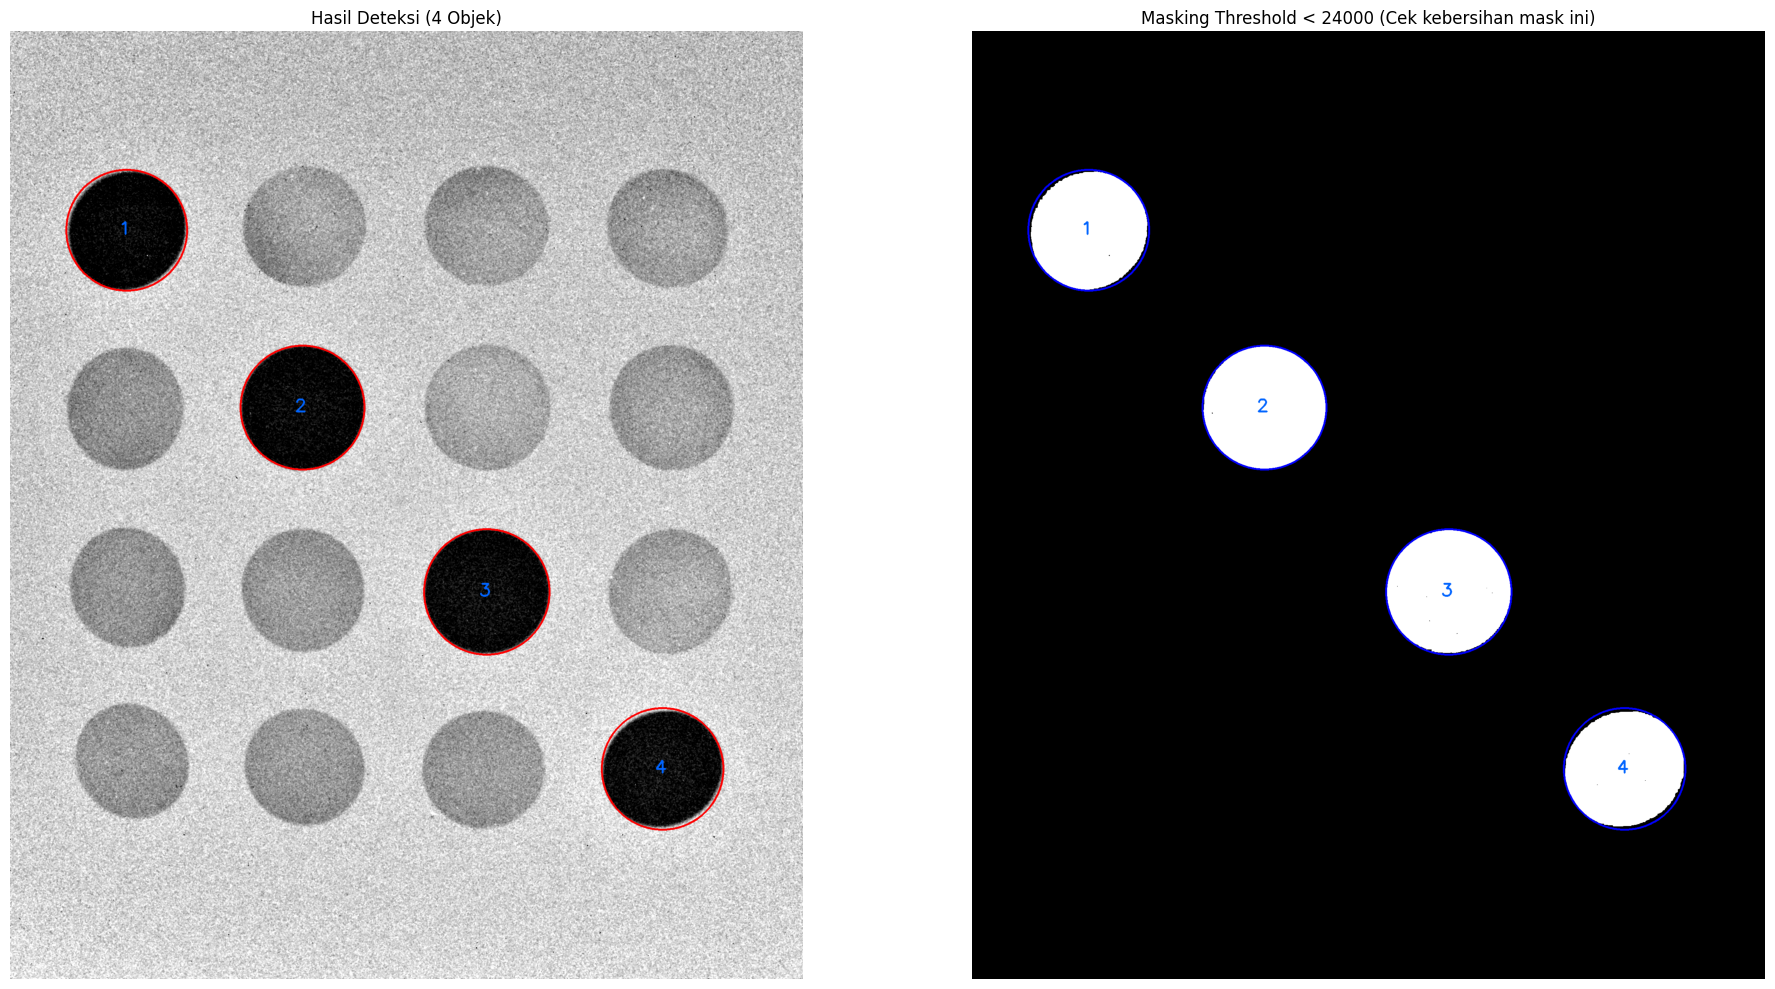

In [17]:
image_file = r"sample-circle.tiff"
process_image(image_file)

## Run Full MIU Analysis (Production Logic)

Run the production-identical circle pipeline end-to-end: detection, grid extrapolation, and differential attenuation (MIU) analysis.

Dimensi Gambar: (2448, 2048)
Jumlah kontur awal ditemukan: 4
Setelah filtering bentuk: 4 objek valid

--- Data Deteksi Final ---
No   | Posisi          | R     | Mean     | Circ   | Solid  | AR     | Class
-------------------------------------------------------------------------------------
1    | (301, 514)      | 156   | 1538.3   | 0.825  | 0.989  | 1.013  | Hitam
2    | (755, 972)      | 160   | 2084.0   | 0.855  | 0.991  | 1.003  | Hitam
3    | (1231, 1448)    | 162   | 2853.2   | 0.854  | 0.991  | 1.013  | Hitam
4    | (1685, 1905)    | 157   | 3206.0   | 0.827  | 0.989  | 1.030  | Hitam


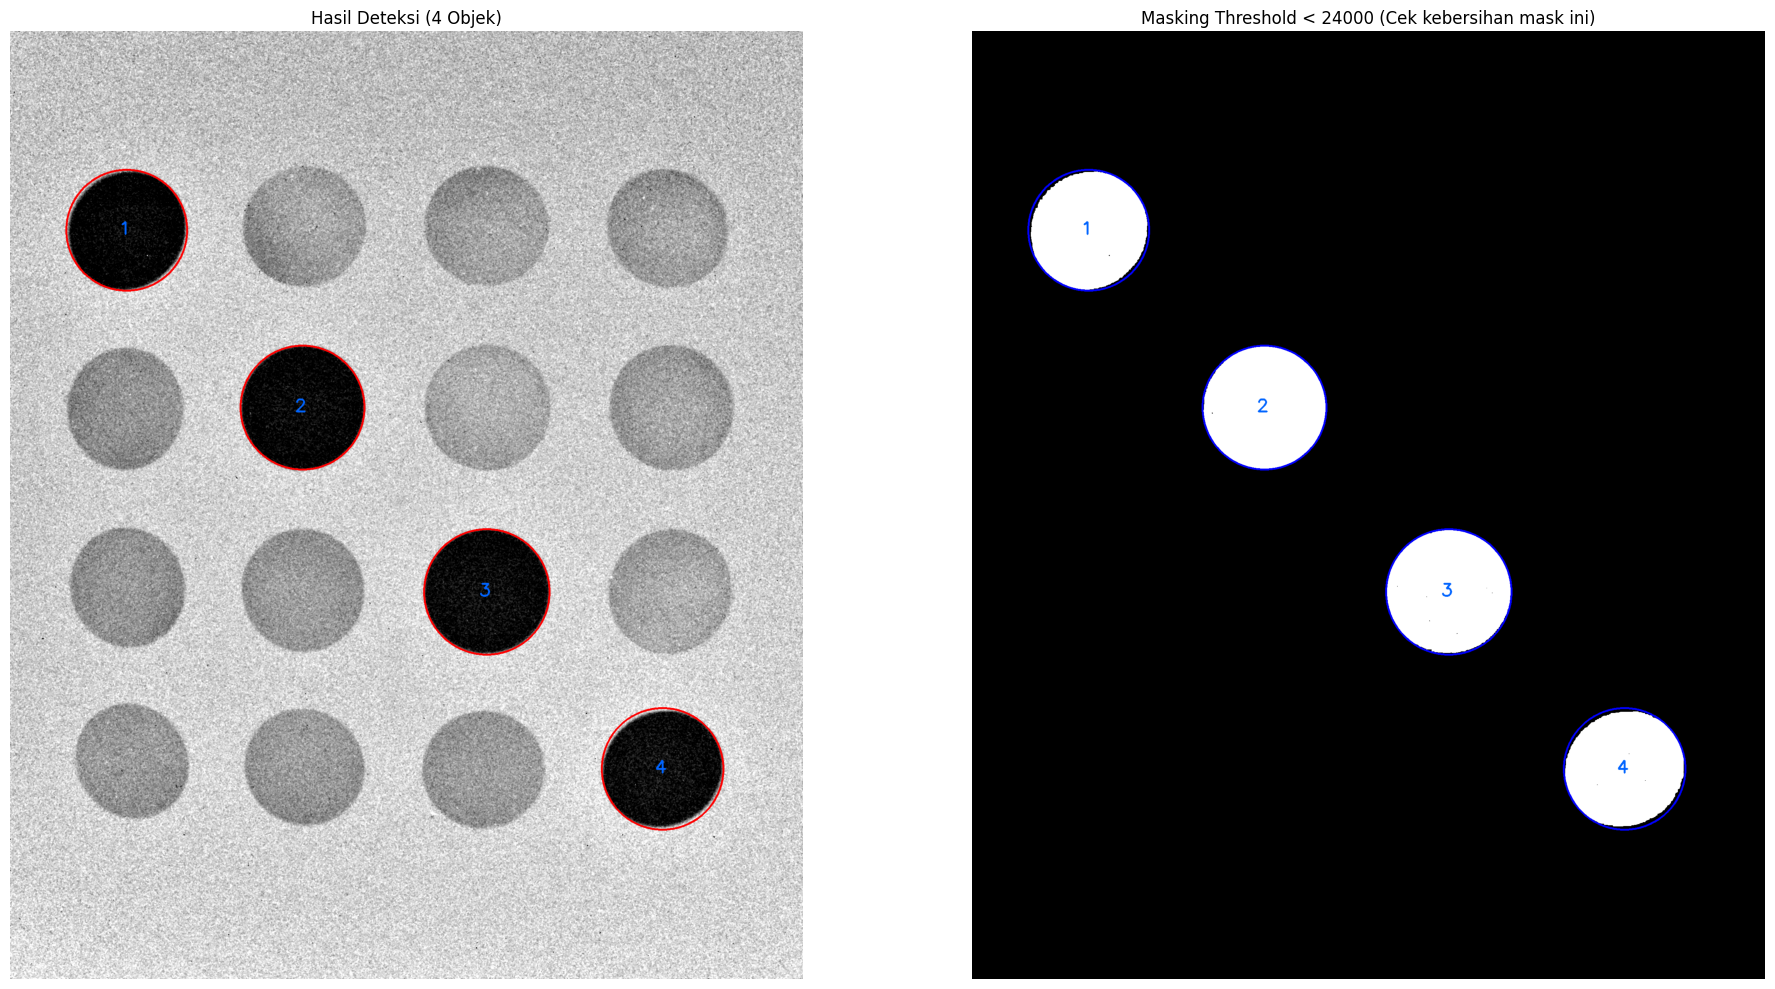

[ WARN:0@617.598] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered


=== Analisis Pola Diagonal ===
Diagonal X: [301, 755, 1231, 1685]
Diagonal Y: [514, 972, 1448, 1905]

X spacing: 461.3px
Y spacing: 463.7px

=== Generate Grid 4x4 ===
X positions (kolom): [301, 762, 1223, 1685]
Y positions (baris): [514, 977, 1441, 1905]

=== Grid 4x4 (16 posisi) ===
[0][0]: (301, 514)
[0][1]: (762, 514)
[0][2]: (1223, 514)
[0][3]: (1685, 514)
[1][0]: (301, 977)
[1][1]: (762, 977)
[1][2]: (1223, 977)
[1][3]: (1685, 977)
[2][0]: (301, 1441)
[2][1]: (762, 1441)
[2][2]: (1223, 1441)
[2][3]: (1685, 1441)
[3][0]: (301, 1905)
[3][1]: (762, 1905)
[3][2]: (1223, 1905)
[3][3]: (1685, 1905)

=== Hasil Grid ===
No   | Grid     | Center              
------------------------------------------------------------
1    | [0,0]  | (301, 514)          
2    | [0,1]  | (762, 514)          
3    | [0,2]  | (1223, 514)         
4    | [0,3]  | (1685, 514)         
5    | [1,0]  | (301, 977)          
6    | [1,1]  | (762, 977)          
7    | [1,2]  | (1223, 977)         
8    | [1,3]  | 

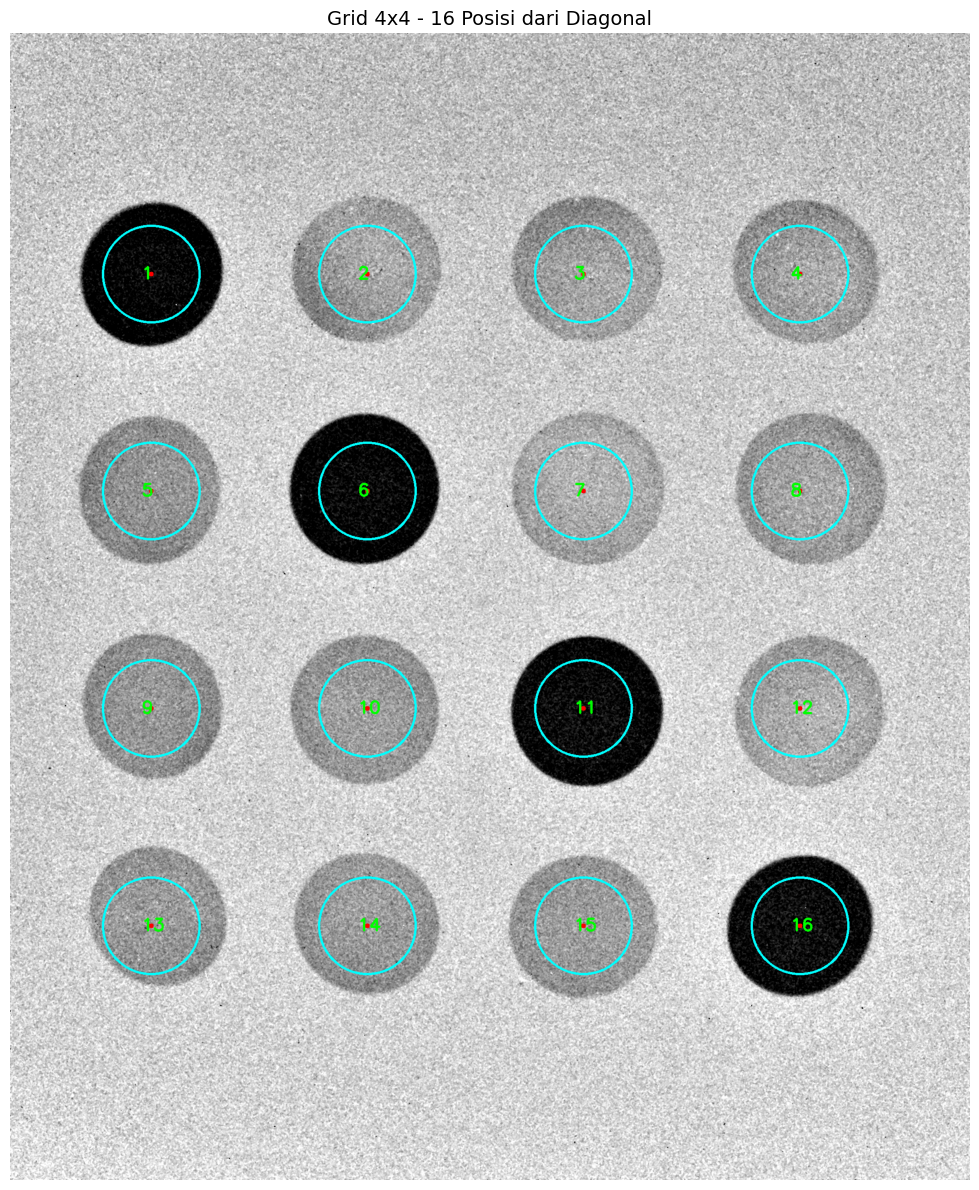

In [ ]:
# End-to-end run using the inlined production functions in Cell 4
image_file = r"sample-circle.tiff"

# Use integration-tested params for stable 4x4 anchors on sample-circle.tiff
detect_params = {
    "threshold_value": 24000,
    "min_diameter": 280,
    "max_diameter": 340,
    "min_circularity": 0.6,
    "min_solidity": 0.7,
    "expected_count": 16,
    "grid_cols": 4,
}

# Keep same tolerance used in integration tests
AIR_CV_THRESHOLD = 0.06

miu_result = run_full_miu_analysis(
    image_file,
    detect_params=detect_params,
    compare_params={"air_cv_threshold": AIR_CV_THRESHOLD},
)

print("=== MIU Summary ===")
summary = miu_result["analysis"]["summary"]
print(f"upper_mu_avg : {summary['upper_mu_avg']:.5f}")
print(f"lower_mu_avg : {summary['lower_mu_avg']:.5f}")
print(f"upper_mu_std : {summary['upper_mu_std']:.5f}")
print(f"lower_mu_std : {summary['lower_mu_std']:.5f}")
print(f"upper_mu_final: {summary['upper_mu_final']:.5f}")
print(f"lower_mu_final: {summary['lower_mu_final']:.5f}")

# Keep compatibility variable names for downstream cells
grid_results = miu_result["grid"]
comparison_result = miu_result["analysis"]

## Histogram Analysis (Production Function)

Use the production histogram analyzer over the extrapolated 4x4 grid.

[ WARN:0@618.501] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered


Grid [0,0] at (301, 514): Mean=2309.9, Median=762.0, Std=3074.1, Range=[0-19834]
Grid [0,1] at (762, 514): Mean=42131.0, Median=42116.0, Std=5387.3, Range=[8738-61155]
Grid [0,2] at (1223, 514): Mean=42141.6, Median=42191.0, Std=5197.4, Range=[22145-64298]
Grid [0,3] at (1685, 514): Mean=42396.5, Median=42350.0, Std=5482.8, Range=[0-63858]
Grid [1,0] at (301, 977): Mean=37897.0, Median=37885.0, Std=4835.1, Range=[14752-65535]
Grid [1,1] at (762, 977): Mean=2817.0, Median=1906.0, Std=3240.6, Range=[0-21076]
Grid [1,2] at (1223, 977): Mean=45430.4, Median=45452.0, Std=4760.9, Range=[27183-64067]
Grid [1,3] at (1685, 977): Mean=42692.3, Median=42725.0, Std=4990.8, Range=[20259-65535]
Grid [2,0] at (301, 1441): Mean=38727.4, Median=38790.0, Std=4797.5, Range=[22010-61961]
Grid [2,1] at (762, 1441): Mean=40549.6, Median=40595.0, Std=4876.9, Range=[22632-60046]
Grid [2,2] at (1223, 1441): Mean=3621.0, Median=3123.0, Std=3587.6, Range=[0-25288]
Grid [2,3] at (1685, 1441): Mean=44139.7, Median

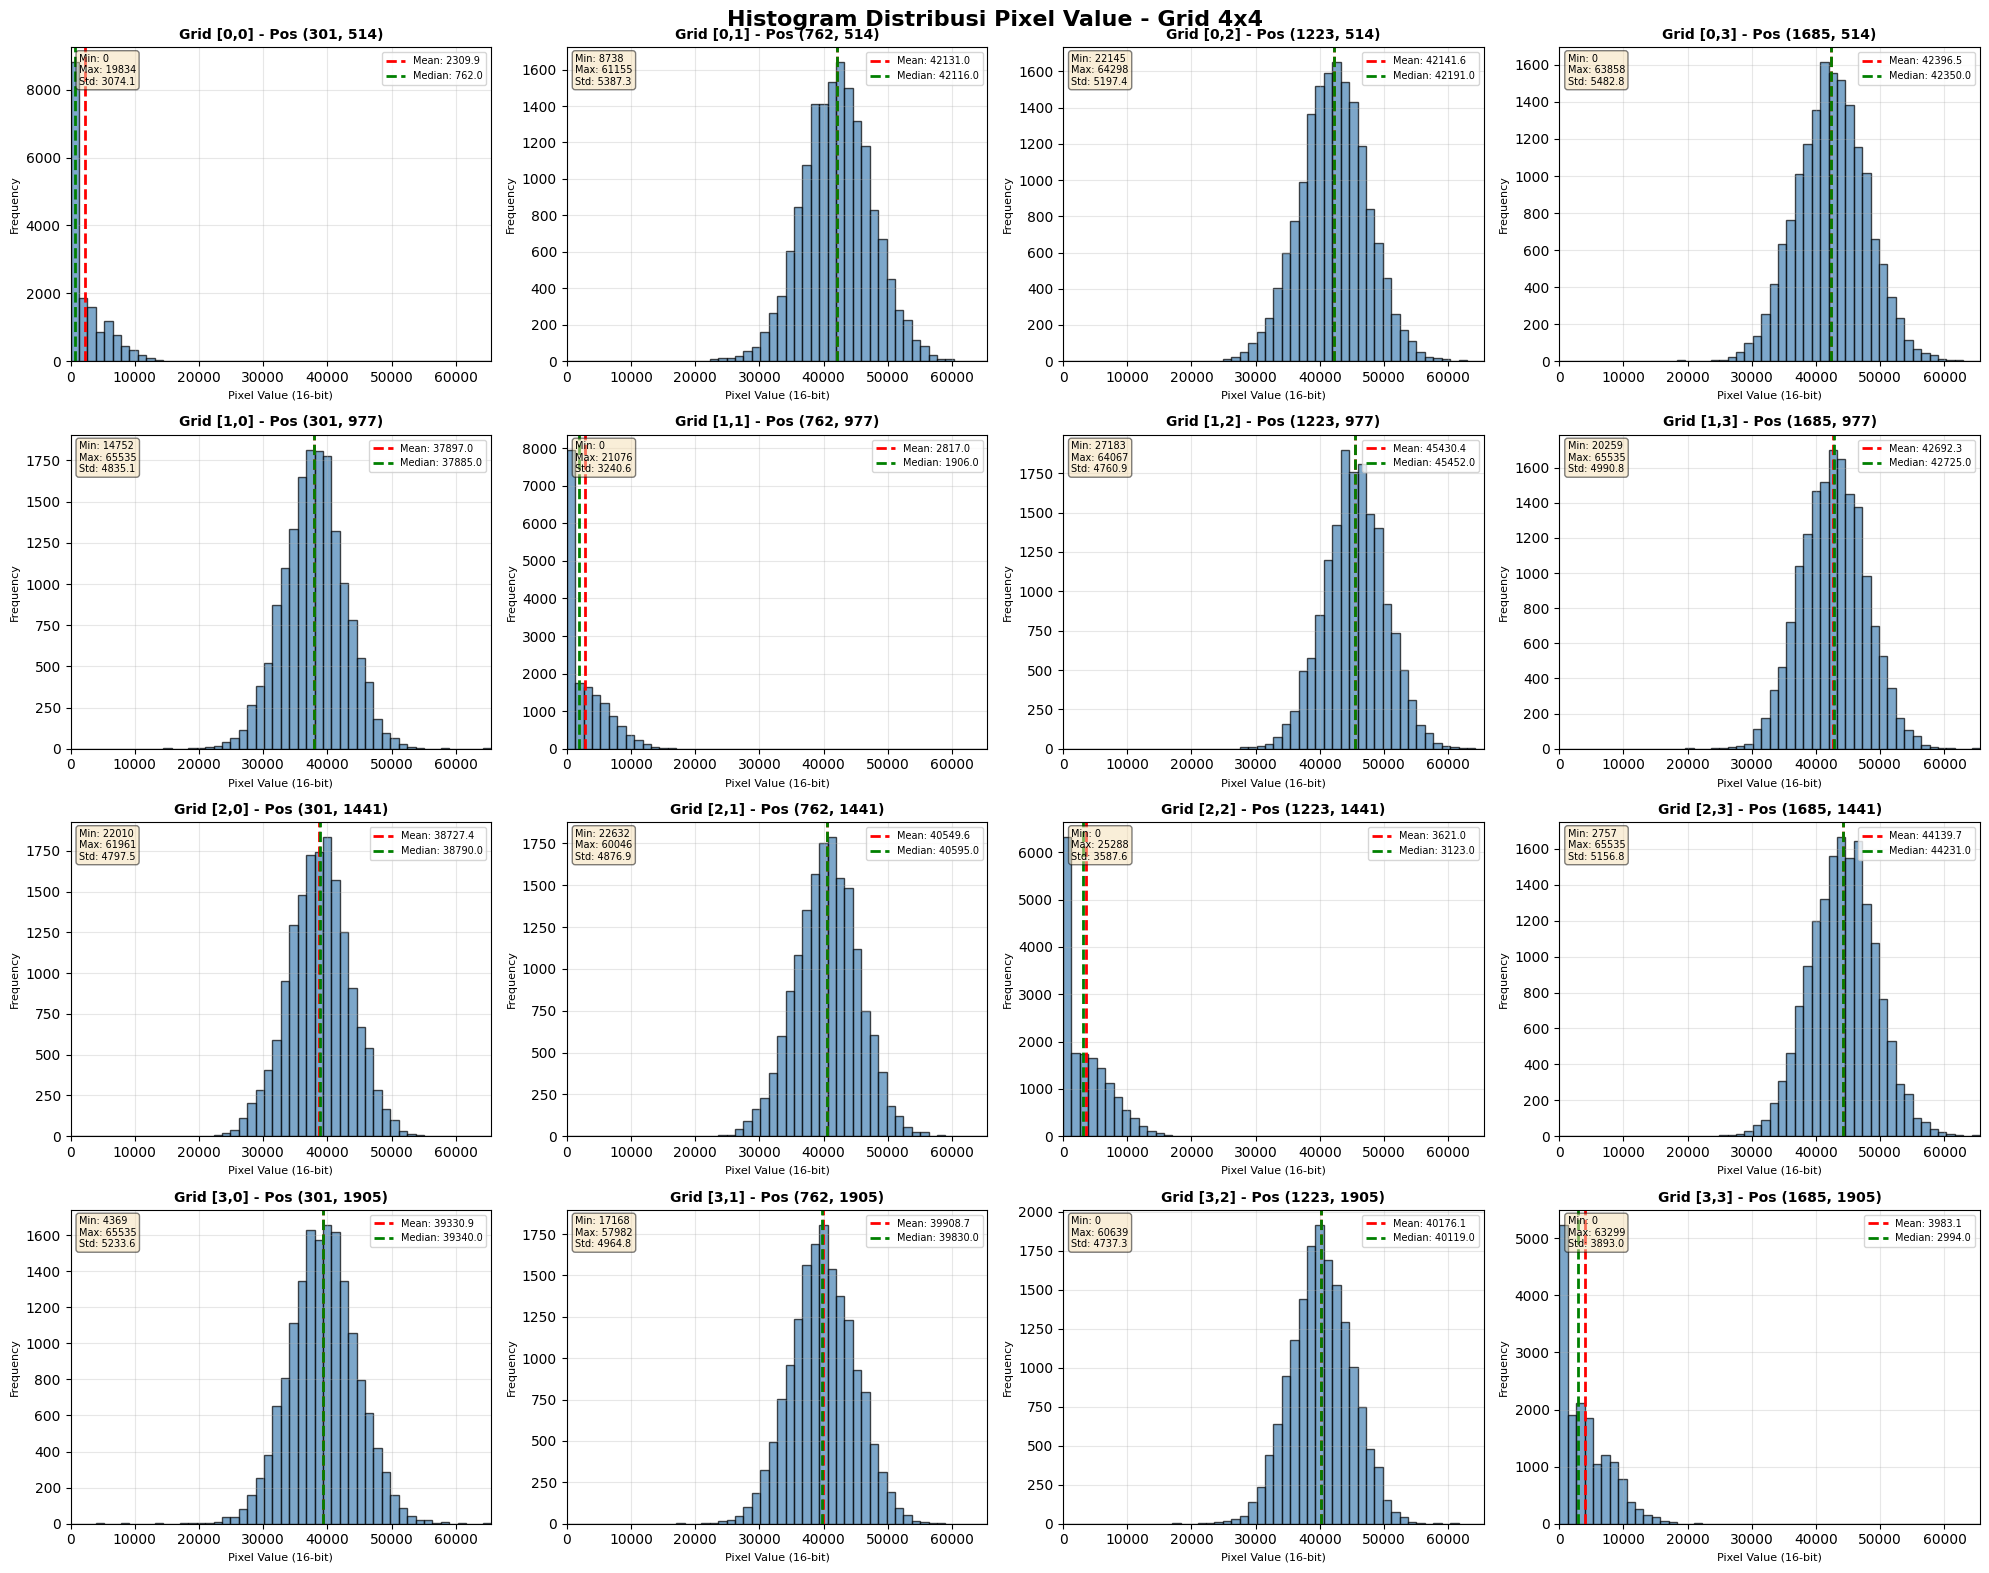

In [ ]:
# Run production histogram analyzer (no function override)
if "grid_results" in locals():
    hist_result = analyze_grid_histograms(image_file, grid_results)
    if hist_result is None:
        print("Histogram analysis returned no result")
    else:
        print("Histogram stats count:", len(hist_result["histogram_stats"]))
        print("ROI area mean:", f"{hist_result['roi_area_mean']:.3f}")
        print("ROI area std :", f"{hist_result['roi_area_std']:.3f}")
else:
    print("Run the MIU analysis cell first.")

## Differential Attenuation (MIU) Output

Display key attenuation metrics from the production compare function output.

[ WARN:0@621.884] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered


=== DIAGONAL COMPARISON ===

--- LOWER DIAGONAL: [1,0], [2,0], [2,1], [3,0], [3,1], [3,2] ---
Grid       | Center           | Mean       | Median     | Std       
--------------------------------------------------------------------------------
(1, 0)     | (301, 977)       | 37897.0    | 37885.0    | 4835.1    
(2, 0)     | (301, 1441)      | 38727.4    | 38790.0    | 4797.5    
(2, 1)     | (762, 1441)      | 40549.6    | 40595.0    | 4876.9    
(3, 0)     | (301, 1905)      | 39330.9    | 39340.0    | 5233.6    
(3, 1)     | (762, 1905)      | 39908.7    | 39830.0    | 4964.8    
(3, 2)     | (1223, 1905)     | 40176.1    | 40119.0    | 4737.3    

Average Mean: 39431.6
Average Median: 39426.5
Std of Means: 903.1

--- UPPER DIAGONAL: [0,1], [0,2], [0,3], [1,2], [1,3], [2,3] ---
Grid       | Center           | Mean       | Median     | Std       
--------------------------------------------------------------------------------
(0, 1)     | (762, 514)       | 42131.0    | 42116.0    | 5

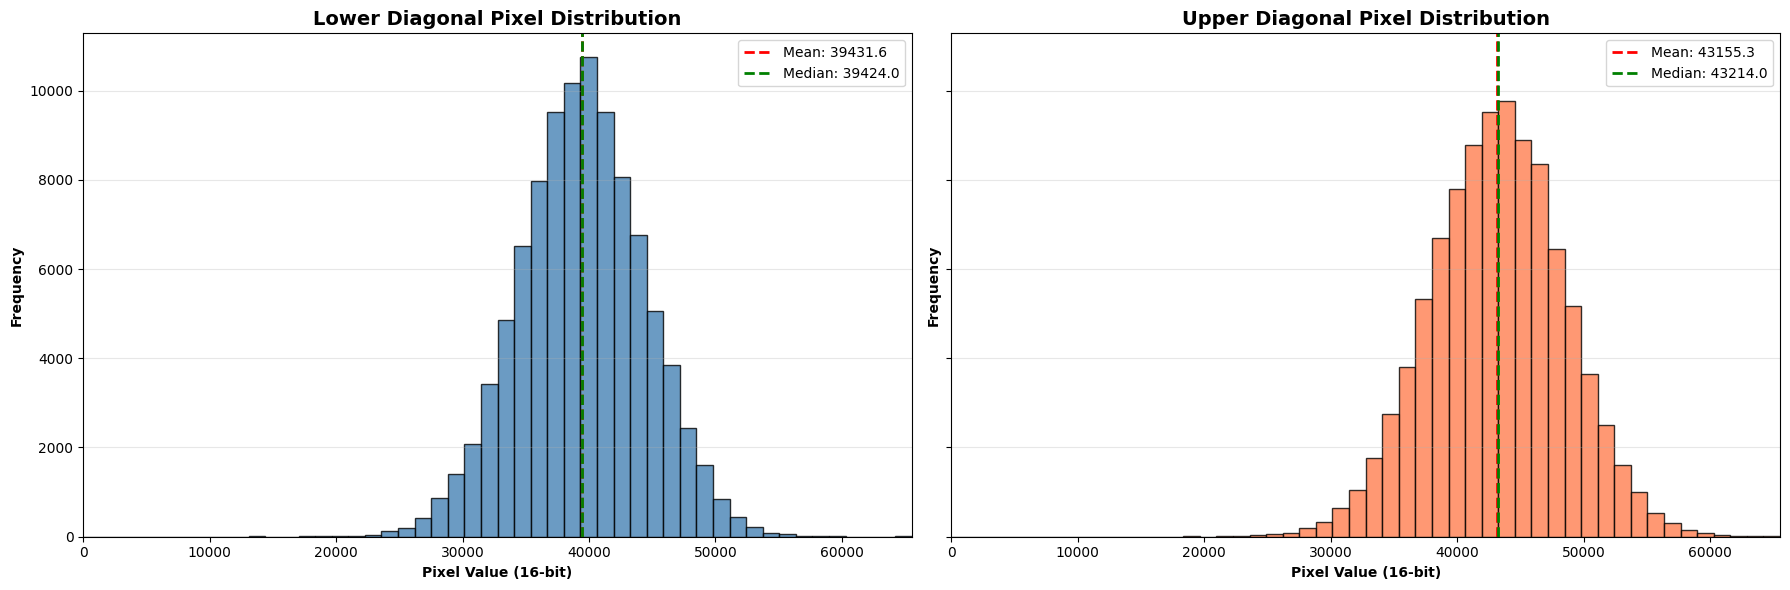

In [ ]:
# Show detailed production MIU outputs (already computed in miu_result)
if "comparison_result" in locals():
    s = comparison_result["summary"]
    print("=== Differential Attenuation Summary ===")
    print(f"p_air          : {s['p_air']:.5f}")
    print(f"x_coal_mm      : {s['x_coal_mm']:.5f}")
    print(f"anti_air_cv    : {s['anti_air_cv']:.5f}")
    print(f"upper_mu_avg   : {s['upper_mu_avg']:.5f}")
    print(f"lower_mu_avg   : {s['lower_mu_avg']:.5f}")
    print(f"upper_mu_std   : {s['upper_mu_std']:.5f}")
    print(f"lower_mu_std   : {s['lower_mu_std']:.5f}")
    print(f"upper_mu_final : {s['upper_mu_final']:.5f}")
    print(f"lower_mu_final : {s['lower_mu_final']:.5f}")

    print("\nUpper stats count:", len(comparison_result["upper_stats"]))
    print("Lower stats count:", len(comparison_result["lower_stats"]))
else:
    print("Run the MIU analysis cell first.")